In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [33]:
raw_data_df = pd.read_csv("../data/raw/vehicles.csv")

In [34]:
processed_data = raw_data_df.copy()

In [51]:
# Custom EDA + basic outlier handling utilities.
def df_num_col(df):
  num_df = df.select_dtypes(include=np.number)
  return num_df


def df_not_num_col(df):
  not_num_df = df.select_dtypes(exclude=np.number)
  return not_num_df


def explore_dataframe(df,dtype_filter = "all"):

  if dtype_filter =='num':
    df = df_num_col(df)

  elif dtype_filter == 'not_num':
    df = df_not_num_col(df)

    return pd.DataFrame({
      'dtype':df.dtypes,
      'non_null_%':df.count() / len(df) * 100,
    'null_%':df.isna().sum() / len(df) * 100,
      'unique_count': df.nunique()
    })

  elif dtype_filter != "all":
      raise ValueError("dtype_filter must be one of: 'all', 'num', 'not_num'")

  return pd.DataFrame({
    'dtype':df.dtypes,
    'non_null_%':df.count() / len(df) * 100,
    'null_%':df.isna().sum() / len(df) * 100,
    'unique_count': df.nunique(),
    'min_val': df.min(numeric_only=True),
    'max_val':df.max(numeric_only=True),
    'quantile_0.01':df.quantile(0.01, numeric_only=True),
    'quantile_0.999':df.quantile(0.999, numeric_only=True)
  })


def remove_max_outliers(df, col, quantile):
  threshold = df[col].quantile(quantile)
  df = df[df[col] <= threshold]
  return df


def remove_min_outliers(df, col, quantile):
  threshold = df[col].quantile(quantile)
  df = df[df[col] >= threshold]
  return df

In [36]:
explore_dataframe(raw_data_df)

,dtype,non_null_%,null_%,unique_count,min_val,max_val,quantile_0.01,quantile_0.999
VIN,str,62.274644,37.725356,118264,NaN,NaN,NaN,NaN
condition,str,59.214768,40.785232,6,NaN,NaN,NaN,NaN
county,float64,0.000000,100.000000,0,NaN,NaN,NaN,NaN
cylinders,str,58.377530,41.622470,8,NaN,NaN,NaN,NaN
description,str,99.983602,0.016398,360911,NaN,NaN,NaN,NaN
drive,str,69.413653,30.586347,3,NaN,NaN,NaN,NaN
fuel,str,99.294181,0.705819,5,NaN,NaN,NaN,NaN
id,int64,100.000000,0.000000,426880,7.207408e+09,7.317101e+09,7.301962e+09,7.317066e+09
image_url,str,99.984070,0.015930,241899,NaN,NaN,NaN,NaN
lat,float64,98.465845,1.534155,53181,-8.412225e+01,8.239082e+01,2.584466e+01,6.159230e+01


In [37]:
# Create time-based features from the listing date and derive vehicle usage metrics.
processed_data['posting_date'] = pd.to_datetime(processed_data['posting_date'], utc = True)
processed_data['posted_year'] = processed_data['posting_date'].dt.year
processed_data['posted_month'] = processed_data['posting_date'].dt.month
processed_data['car_age'] = processed_data['posted_year'] - processed_data['year']
safe_age = processed_data['car_age'].replace(0,1)
processed_data['car_miles_per_year'] = processed_data['odometer'] / safe_age

In [38]:
'''
Feature Selection / Data Cleaning
Drop columns with high missing rates (>40%) or low modeling value (IDs, URLs, text fields, geographic noise). These features are removed to reduce noise and keep only relevant variables for the initial model.
'''
processed_data = processed_data.drop(columns=['id','url','region','region_url','image_url','posted_month','posted_year','posting_date','description','model','long','lat','VIN','size','county','cylinders'])

In [11]:
explore_dataframe(processed_data, 'num')

,dtype,non_null_%,null_%,unique_count,min_val,max_val,quantile_0.01,quantile_0.999
price,int64,100.000000,0.000000,15655,0.0,3.736929e+09,0.00000,120000.000
year,float64,99.717719,0.282281,114,1900.0,2.022000e+03,1967.00000,2021.000
odometer,float64,98.969265,1.030735,104870,0.0,1.000000e+07,2.00000,1111111.000
car_age,float64,99.717719,0.282281,114,-1.0,1.210000e+02,1.00000,89.000
car_miles_per_year,float64,98.703148,1.296852,134372,-10000000.0,1.000000e+07,0.47363,129785.625


price.describe()
 count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
max      3.736929e+09
Name: price, dtype: float64
price,quantile = 0.11:
 1000.0
price,quantile = 0.99:
 66995.0
value_counts()
 price  year    manufacturer  condition  fuel    odometer  title_status  transmission  drive  type    paint_color  state  car_age  car_miles_per_year
100    2011.0  jeep          excellent  gas     100000.0  clean         automatic     4wd    SUV     red          oh     10.0     10000.000000          53
1      2016.0  jeep          excellent  gas     57722.0   clean         other         4wd    wagon   white        fl     5.0      11544.400000          31
0      2017.0  toyota        like new   gas     80000.0   clean         automatic     fwd    sedan   silver       fl     4.0      20000.000000          26
250    2011.0  jeep          excellent  gas     100000.0  clean         automatic    

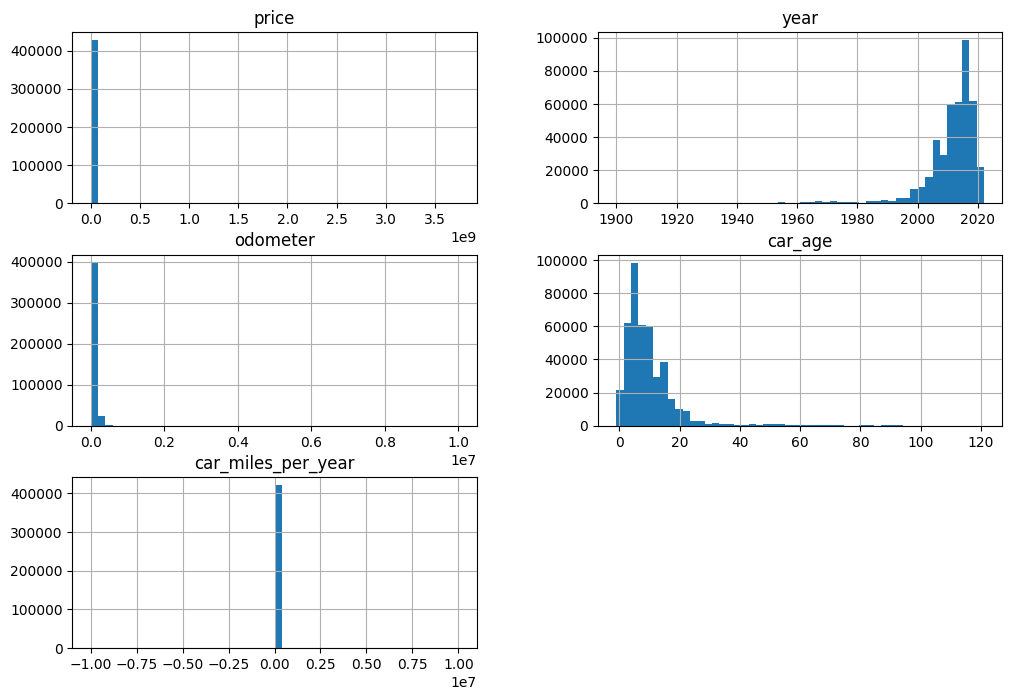

In [39]:
# Inspect numeric features and their distributions using summary statistics, quantiles, and histograms to identify potential outliers and understand the data distribution before further preprocessing.
print('price.describe()\n',processed_data["price"].describe())
print('price,quantile = 0.11:\n',processed_data['price'].quantile(0.11))
print('price,quantile = 0.99:\n',processed_data['price'].quantile(0.99))
print('value_counts()\n', processed_data.value_counts().head(20))
print('year, quantile = 0.05:\n',processed_data['year'].quantile(0.05))
print('year, quantile = 0.999:\n',processed_data['year'].quantile(0.999))
print('odometer, quantile = 0.997:\n',processed_data['odometer'].quantile(0.99))
print('car-miles-per-year,quantile = 0.99:\n',processed_data['car_miles_per_year'].quantile(0.99))
processed_data.hist(bins = 50, figsize=(12,8))
plt.show()


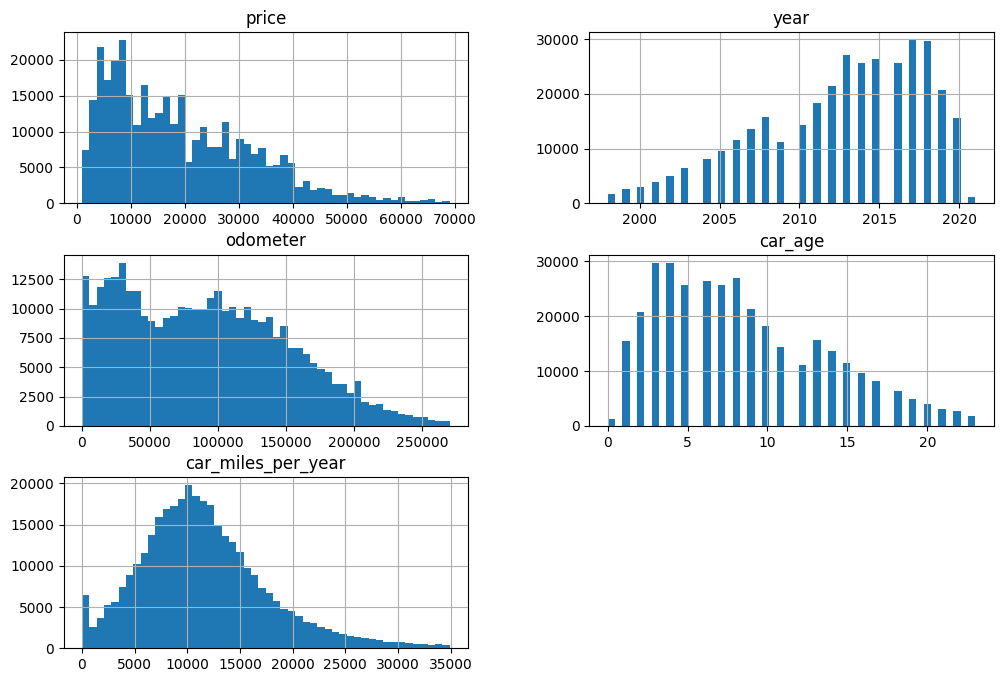

In [40]:
# Outlier Removal (3-Sigma principle)

# Extreme values were removed using quantile thresholds approximating the 3-sigma rule to eliminate unrealistic listings and stabilize the feature distributions before modeling.

processed_data = remove_min_outliers(processed_data, 'price', 0.11)
processed_data = remove_max_outliers(processed_data, 'price', 0.99)
processed_data = remove_min_outliers(processed_data, 'year', 0.05)
processed_data = remove_max_outliers(processed_data, 'year', 0.999)
processed_data = remove_max_outliers(processed_data, 'odometer', 0.99)
processed_data = remove_max_outliers(processed_data, 'car_miles_per_year', 0.99)
processed_data.hist(bins = 50, figsize=(12,8))
plt.show()

In [52]:
explore_dataframe(processed_data, 'not_num')

,dtype,non_null_%,null_%,unique_count
manufacturer,str,97.156841,2.843159,40
condition,str,62.126862,37.873138,4
fuel,str,99.409109,0.590891,5
title_status,str,98.312317,1.687683,4
transmission,str,99.588920,0.411080,3
drive,str,69.763354,30.236646,3
type,str,79.759365,20.240635,11
paint_color,str,71.756890,28.243110,12
state,str,100.000000,0.000000,51


In [48]:
print('manufacturer%',processed_data['manufacturer'].value_counts(normalize=True).mul(100).round(2))
print('condition%',processed_data['condition'].value_counts(normalize=True).mul(100).round(2))
print('fuel%',processed_data['fuel'].value_counts(normalize=True).mul(100).round(2))
print('title_status%',processed_data['title_status'].value_counts(normalize=True).mul(100).round(2))
print('transmission%',processed_data['transmission'].value_counts(normalize=True).mul(100).round(2))
print('drive%',processed_data['drive'].value_counts(normalize=True).mul(100).round(2))
print('type%',processed_data['type'].value_counts(normalize=True).mul(100).round(2))
print('paint_color%',processed_data['paint_color'].value_counts(normalize=True).mul(100).round(2))
print('state%',processed_data['state'].value_counts(normalize=True).mul(100).round(2))

manufacturer% manufacturer
ford               16.69
chevrolet          12.62
toyota              8.57
honda               5.51
nissan              4.77
jeep                4.48
ram                 4.33
gmc                 4.02
bmw                 3.83
dodge               3.17
mercedes-benz       2.68
hyundai             2.64
subaru              2.52
volkswagen          2.33
lexus               2.18
kia                 2.11
audi                2.04
cadillac            1.73
acura               1.60
chrysler            1.55
mazda               1.40
buick               1.38
infiniti            1.29
lincoln             1.11
volvo               0.87
mitsubishi          0.83
mini                0.65
rover               0.52
jaguar              0.51
pontiac             0.50
porsche             0.32
saturn              0.30
mercury             0.25
alfa-romeo          0.24
tesla               0.23
fiat                0.21
harley-davidson     0.04
aston-martin        0.00
land rover          0.0

In [43]:
# Filtering Non-Relevant Vehicle Categories

# Removed listings that do not represent typical used cars (e.g., motorcycles, buses, off-road vehicles) and excluded unrealistic or irrelevant conditions and title statuses to keep the dataset focused on standard passenger vehicle sales.

processed_data = processed_data.loc[~processed_data['manufacturer'].isin(['harley-davidson'])]
processed_data = processed_data.loc[~processed_data['condition'].isin(['new','salvage'])]
processed_data = processed_data.loc[~processed_data['title_status'].isin(['missing','parts only'])]
processed_data = processed_data.loc[~processed_data['type'].isin(['offroad','bus'])]

In [56]:
# Train–Test Split
train_set, test_set = train_test_split(processed_data, test_size=0.1, random_state = 42)

In [57]:
train_set.to_csv("../data/processed/train_set.csv", index=False)
test_set.to_csv("../data/processed/test_set.csv", index=False)